In [1]:
using Random, Statistics, Plots, ProgressMeter

In [2]:
# -------------------------------
# Chromosomes Type and Functions
# -------------------------------
mutable struct Chromosomes
    chromosomes_gene_type::Vector{Vector{Int}}
    chromosomes_gene_mut::Vector{Vector{Int}}
    gene_map::Dict{Int,String}
end

function get_Nchrs(ch::Chromosomes)
    if length(ch.chromosomes_gene_type) == length(ch.chromosomes_gene_mut)
        return length(ch.chromosomes_gene_type)
    else
        error("Mismatched chromosome lists.")
    end
end

function mutate!(ch::Chromosomes, mu::Float64)
    n_mut = 0
    for i in 1:get_Nchrs(ch)
        chrom = ch.chromosomes_gene_mut[i]
        # For each gene in the chromosome, mutate with probability mu.
        for j in 1:length(chrom)
            if rand() < mu
                chrom[j] = 1
            end
        end
        ch.chromosomes_gene_mut[i] = chrom
    end
end

function crossover!(ch::Chromosomes, ext_chr_gt::Vector{Int}, ext_chr_gm::Vector{Int})
    idx_chr = rand(1:get_Nchrs(ch))
    ch.chromosomes_gene_type[idx_chr] = vcat(ch.chromosomes_gene_type[idx_chr], ext_chr_gt)
    ch.chromosomes_gene_mut[idx_chr]  = vcat(ch.chromosomes_gene_mut[idx_chr], ext_chr_gm)
end

function get_genes_by_type(ch::Chromosomes, gene_type::String)
    restr_gene_mut_gt = Vector{Vector{Int}}()
    restr_gene_mut_gm = Vector{Vector{Int}}()
    for i in 1:length(ch.chromosomes_gene_type)
        mapped = [ch.gene_map[x] for x in ch.chromosomes_gene_type[i]]
        inds = findall(x -> x == gene_type, mapped)
        push!(restr_gene_mut_gt, ch.chromosomes_gene_type[i][inds])
        push!(restr_gene_mut_gm, ch.chromosomes_gene_mut[i][inds])
    end
    return restr_gene_mut_gt, restr_gene_mut_gm
end


get_genes_by_type (generic function with 1 method)

In [3]:
# ---------------------
# Cell Type and Methods
# ---------------------
mutable struct Cell
    x::Int
    y::Int
    chromosomes::Chromosomes
    mu0::Float64
    dmu::Float64
    mumax::Float64
    mu::Float64
    r0::Float64
    dr::Float64
    rmax::Float64
    r::Float64
end

get_Nchrs(cell::Cell) = get_Nchrs(cell.chromosomes)

"""
    compute_activation(cell, gene_type; mode="any")

Helper function that computes, for a given gene type, an activation Boolean vector
across the unique genes. For mode "any", a gene is activated if at least one chromosome
has it mutated; for mode "all", only if all chromosomes show the mutation.
"""
function compute_activation(cell::Cell, gene_type::String; mode::String="any")
    gene_types, gene_muts = get_genes_by_type(cell.chromosomes, gene_type)
    if all(x -> isempty(x), gene_types)
        return Bool[]
    end
    unique_genes = unique(vcat(gene_types...))
    # For each chromosome, build a Boolean vector indicating for each unique gene if any matching gene is mutated.
    if mode == "any"
        # A gene is activated if any chromosome shows it.
        activation = [ [ any(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ any(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    elseif mode == "all"
        # A gene is activated only if every chromosome shows it.
        activation = [ [ all(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ all(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    else
        error("Invalid mode. Use \"any\" or \"all\".")
    end
end

function update_mu!(cell::Cell)
    act = compute_activation(cell, "I"; mode="any")
    new_mu = cell.mu0 + sum(act) * cell.dmu
    cell.mu = new_mu < cell.mumax ? new_mu : cell.mumax
end

function update_r!(cell::Cell)
    act_o = compute_activation(cell, "O"; mode="any")
    act_s = compute_activation(cell, "S"; mode="all")
    new_r = cell.r0 + (sum(act_o) + sum(act_s)) * cell.dr
    cell.r = new_r < cell.rmax ? new_r : cell.rmax
end

reproduce(cell::Cell) = rand() < cell.r

function check_cell_death(cell::Cell)
    if get_Nchrs(cell) == 0
        return true
    end
    act_hk = compute_activation(cell, "HK"; mode="all")
    return any(act_hk)
end

"""
    update!(cell)

Updates the cell state: first checks for cell death, then applies mutation, and updates
the mutation and reproduction rates. Returns 0 if the cell dies, 1 if it reproduces,
or 2 if nothing happens.
"""
function update!(cell::Cell)
    if check_cell_death(cell)
        return 0  # Death
    end
    mutate!(cell.chromosomes, cell.mu)
    update_mu!(cell)
    update_r!(cell)
    return reproduce(cell) ? 1 : 2
end

function copy_cell(cell::Cell)
    new_chromosomes = Chromosomes([copy(arr) for arr in cell.chromosomes.chromosomes_gene_type],
                                  [copy(arr) for arr in cell.chromosomes.chromosomes_gene_mut],
                                  deepcopy(cell.chromosomes.gene_map))
    return Cell(cell.x, cell.y, new_chromosomes, cell.mu0, cell.dmu, cell.mumax,
                cell.mu, cell.r0, cell.dr, cell.rmax, cell.r)
end

"""
    replicate_split_chromosomes(cell)

Replicates a cell while splitting one randomly selected chromosome.
The mother loses the selected chromosome and the daughter gains an extra copy.
"""
function replicate_split_chromosomes(cell::Cell)
    n_chrs = get_Nchrs(cell)
    idx_chr = rand(1:n_chrs)
    mother = copy_cell(cell)
    daughter = copy_cell(cell)
    # Remove the selected chromosome from the mother.
    splice!(mother.chromosomes.chromosomes_gene_type, idx_chr)
    splice!(mother.chromosomes.chromosomes_gene_mut, idx_chr)
    # Append a copy of the selected chromosome to the daughter.
    push!(daughter.chromosomes.chromosomes_gene_type, copy(daughter.chromosomes.chromosomes_gene_type[idx_chr]))
    push!(daughter.chromosomes.chromosomes_gene_mut, copy(daughter.chromosomes.chromosomes_gene_mut[idx_chr]))
    return mother, daughter
end




replicate_split_chromosomes

In [4]:
# -------------------------
# Tissue Type and Functions
# -------------------------
mutable struct Tissue
    L::Int
    cells::Array{Cell,2}
    p_poly::Float64
    gene_map::Dict{Int,String}
    neighbor_cache::Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}
end

function compute_neighbors(L::Int, row::Int, col::Int)
    neighbors = Vector{Tuple{Int,Int}}()
    for dr in -1:1
        for dc in -1:1
            if dr == 0 && dc == 0
                continue
            end
            new_row = row + dr
            new_col = col + dc
            if new_row ≥ 1 && new_row ≤ L && new_col ≥ 1 && new_col ≤ L
                push!(neighbors, (new_row, new_col))
            end
        end
    end
    return neighbors
end

function Tissue(L::Int, init_cell_state::Array{Cell,2}, p_poly::Float64)
    gene_map = init_cell_state[1,1].chromosomes.gene_map
    neighbor_cache = Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}()
    for i in 1:L, j in 1:L
        neighbor_cache[(i,j)] = compute_neighbors(L, i, j)
    end
    return Tissue(L, init_cell_state, p_poly, gene_map, neighbor_cache)
end

get_neighbors(tiss::Tissue, row::Int, col::Int) = tiss.neighbor_cache[(row, col)]

function get_actions(tiss::Tissue)
    actions = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        actions[i, j] = update!(tiss.cells[i,j])
    end
    return actions
end

# Helper function for weighted random selection.
function weighted_choice(neighbors::Vector{Tuple{Int,Int}}, weights::Vector{Float64})
    total = sum(weights)
    r = rand() * total
    cum = 0.0
    for (i, w) in enumerate(weights)
        cum += w
        if r < cum
            return neighbors[i]
        end
    end
    return neighbors[end]
end

"""
    substitute!(tiss, action)

For cells that died (action 0), replace them with a copy of a neighbor chosen
with probability proportional to its reproduction rate.
For cells that reproduced (action 1), a neighbor is replaced by a copy of the cell,
or by a split replication with probability p_poly, choosing a neighbot with probability
inversely proportional to the reproduction rate
"""
function substitute!(tiss::Tissue, action::Array{Int,2})
    L = tiss.L
    # Process death cells.
    for i in 1:L, j in 1:L
        if action[i, j] == 0
            neighs = get_neighbors(tiss, i, j)
            rates = [tiss.cells[r, c].r for (r, c) in neighs]
            chosen = weighted_choice(neighs, rates)
            tiss.cells[i, j] = copy_cell(tiss.cells[chosen[1], chosen[2]])
        end
    end
    # Process reproducing cells.
    for i in 1:L, j in 1:L
        if action[i, j] == 1
            neighs = get_neighbors(tiss, i, j)
            rates = [tiss.cells[r, c].r for (r, c) in neighs]
            inv_rates = 1.0 ./ rates
            chosen = weighted_choice(neighs, inv_rates)
            if rand() < tiss.p_poly
                mother, daughter = replicate_split_chromosomes(tiss.cells[i,j])
                tiss.cells[i, j] = mother
                tiss.cells[chosen[1], chosen[2]] = daughter
            else
                tiss.cells[chosen[1], chosen[2]] = copy_cell(tiss.cells[i,j])
            end
        end
    end
end

function update!(tiss::Tissue)
    action = get_actions(tiss)
    substitute!(tiss, action)
    return action
end

function get_r(tiss::Tissue)
    r_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        r_mat[i, j] = tiss.cells[i,j].r
    end
    return r_mat
end

function get_mu(tiss::Tissue)
    mu_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        mu_mat[i, j] = tiss.cells[i,j].mu
    end
    return mu_mat
end

function get_Nchrs(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = get_Nchrs(tiss.cells[i,j])
    end
    return n_mat
end

function get_avg_genemutation(tiss::Tissue, gene_types::Vector{String})
    # Determine indices of genes matching the provided gene_types.
    selected_indices = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_indices, k)
            end
        end
    end
    selected_indices = unique(selected_indices)
    mut_state = fill(NaN, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        if get_Nchrs(tiss.cells[i,j]) == 0
            mut_state[i,j] = NaN
        else
            means = Float64[]
            for chrom in tiss.cells[i,j].chromosomes.chromosomes_gene_mut
                if !isempty(selected_indices)
                    push!(means, mean(chrom[selected_indices]))
                end
            end
            mut_state[i,j] = mean(means)
        end
    end
    return mut_state
end


get_avg_genemutation (generic function with 1 method)

In [5]:
# --------------------
# Tissue Initialization
# --------------------
function init_tissue(L::Int, chrom_gene_type::Vector{Vector{Int}}, chrom_gene_mut::Vector{Vector{Int}}, 
    gene_map::Dict{Int,String}, mu0::Float64, dmu::Float64, mumax::Float64, 
    r0::Float64, dr::Float64, rmax::Float64)
cells = Array{Cell}(undef, L, L)
for i in 1:L, j in 1:L
ch = Chromosomes(copy(chrom_gene_type), copy(chrom_gene_mut), gene_map)
cells[i,j] = Cell(i, j, ch, mu0, dmu, mumax, mu0, r0, dr, rmax, r0)
end
return cells
end

init_tissue (generic function with 1 method)

In [6]:
gene_map = Dict(
    1 => "I",
    2 => "I",
    3 => "I",
    4 => "I",
    5 => "I",
    6 => "I",
    7 => "O",
    8 => "O",
    9 => "O",
    10 => "O",
    11 => "S",
    12 => "S",
    13 => "S",
    14 => "S",
    15 => "HK",
    16 => "HK"
)

Dict{Int64, String} with 16 entries:
  5  => "I"
  16 => "HK"
  7  => "O"
  12 => "S"
  8  => "O"
  1  => "I"
  4  => "I"
  6  => "I"
  13 => "S"
  2  => "I"
  10 => "O"
  11 => "S"
  9  => "O"
  15 => "HK"
  14 => "S"
  3  => "I"

In [65]:
# --------------------
# Model and Simulation
# --------------------
# Model parameters
chrom_gene_type = [collect(1:16), collect(1:16)]
chrom_gene_mut  = [zeros(Int, 16), zeros(Int, 16)]
L = 50
mu0   = 1e-8
dmu   = 5e-4
mumax = 1e-1
r0    = 1e-2
dr    = 1e-3
rmax  = 3 * r0
p_poly = 5e-5

init_state = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, dmu, mumax, r0, dr, rmax)

# Introduce a perturbation in the central cell.
# For the perturbation, we add a third chromosome with a mutation.
pert_chrom_gene_type = [collect(1:16), collect(1:16)]
pert_chrom_gene_mut  = [zeros(Int, 16), zeros(Int, 16)]
# In Julia, index 2 corresponds to the second gene (since indexing starts at 1).
pert_chrom_gene_mut[2][2] = 1
pert_chrom_gene_mut[1][6] = 1
ch_pert = Chromosomes(pert_chrom_gene_type, pert_chrom_gene_mut, gene_map)
center = div(L, 2)
init_state[center, center] = Cell(center, center, ch_pert, mu0, dmu, mumax, mu0, r0, dr, rmax, r0)

# Create the tissue.
tiss = Tissue(L, init_state, p_poly)

Tissue(50, Cell[Cell(1, 1, Chromosomes([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], Dict(5 => "I", 16 => "HK", 7 => "O", 12 => "S", 8 => "O", 1 => "I", 4 => "I", 6 => "I", 13 => "S", 2 => "I"…)), 1.0e-8, 0.0005, 0.1, 1.0e-8, 0.01, 0.001, 0.03, 0.01) Cell(1, 2, Chromosomes([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], Dict(5 => "I", 16 => "HK", 7 => "O", 12 => "S", 8 => "O", 1 => "I", 4 => "I", 6 => "I", 13 => "S", 2 => "I"…)), 1.0e-8, 0.0005, 0.1, 1.0e-8, 0.01, 0.001, 0.03, 0.01) … Cell(1, 49, Chromosomes([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]], [[0, 0, 0, 0, 0, 0, 0, 0, 0,

In [66]:
# Initialize system
init_state[center, center] = Cell(center, center, ch_pert, mu0, dmu, mumax, mu0, r0, dr, rmax, r0)
tiss = Tissue(L, init_state, p_poly)
mus = Float64[]
rs = Float64[]

Float64[]

Progress: 100%|█████████████████████████████████████████| Time: 0:00:28


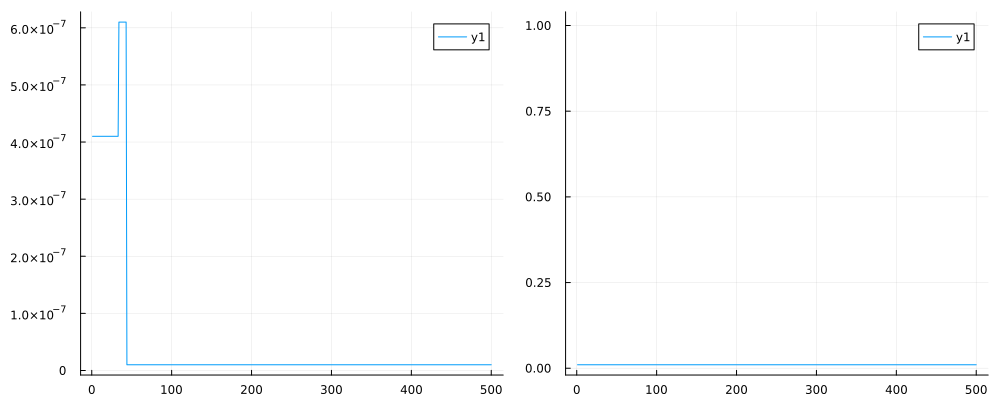

In [67]:
# Simulation loop
@showprogress for k in 1:500
    update!(tiss)
    push!(mus, mean(get_mu(tiss)))
    push!(rs, mean(get_r(tiss)))
end

pmu = plot(mus)
pr = plot(rs)
plot(pmu, pr, layout = (1, 2), size = (1000, 400))

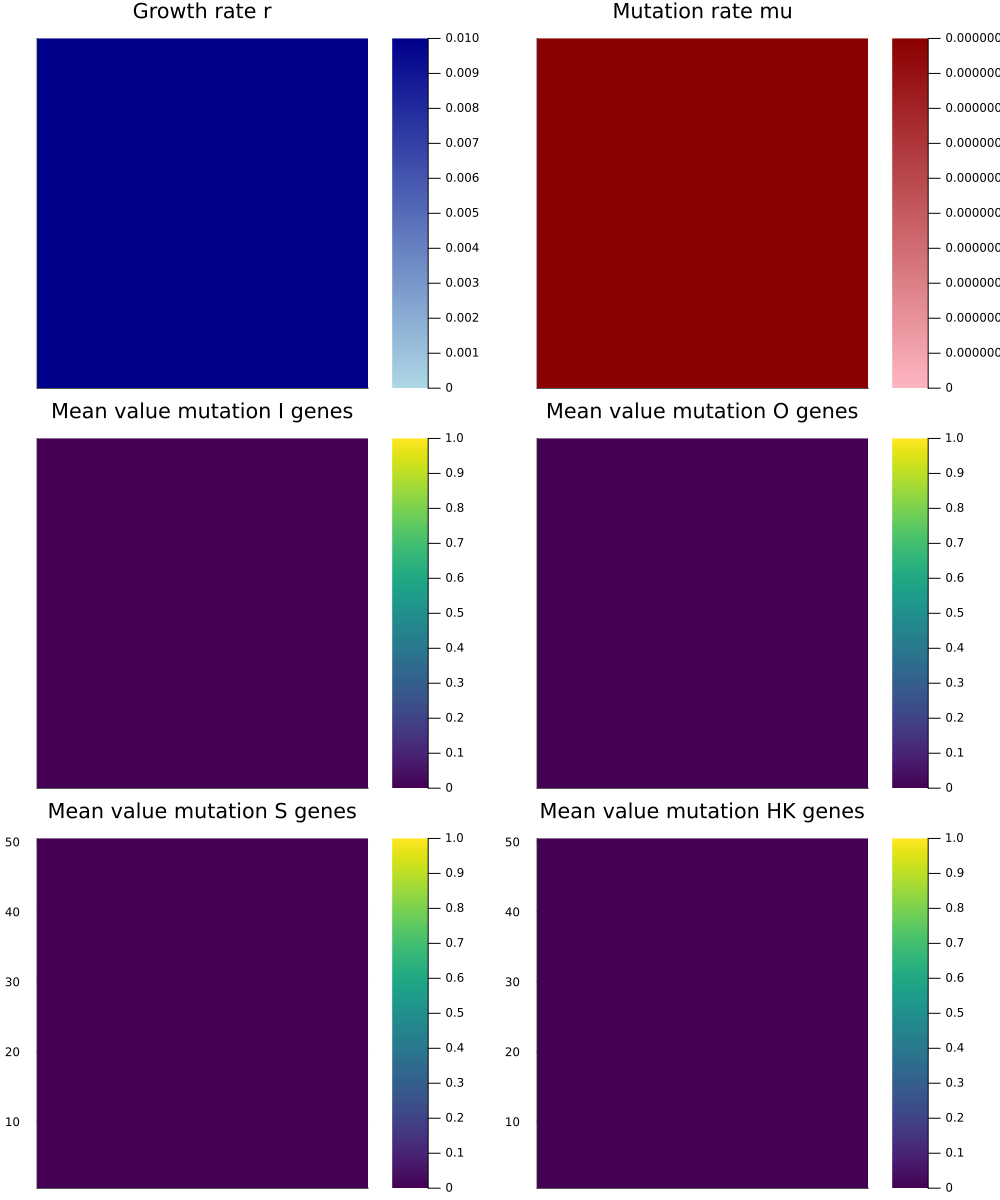

In [64]:
# Create the individual heatmap plots:
p1 = heatmap(get_r(tiss),
             color = :blues,
             #clims = (r0, rmax),
             title = "Growth rate r",
             xticks = false,
             yticks = false)

p2 = heatmap(get_mu(tiss),
             color = :reds,
             #clims = (0, 5), # adjust as needed
             title = "Mutation rate mu",
             xticks = false,
             yticks = false)
gtype_p3 = ["I"]
p3 = heatmap(get_avg_genemutation(tiss, gtype_p3),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p3, "-") * " genes",
             xticks = false,
             yticks = false)
gtype_p4 = ["O"]
p4 = heatmap(get_avg_genemutation(tiss, gtype_p4),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p4, "-") * " genes",
             xticks = false,
             yticks = false)
gtype_p5 = ["S"]
p5 = heatmap(get_avg_genemutation(tiss, gtype_p5),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p5, "-") * " genes",
             xticks = false)
gtype_p6 = ["HK"]
p6 = heatmap(get_avg_genemutation(tiss, gtype_p6),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p6, "-") * " genes",
             xticks = false)

# Combine the subplots in a 2x2 grid.
plot(p1, p2, p3, p4,p5,p6, layout = (3, 2), size = (1000, 1200))